# Contact Simulation Assignment
In this task, we will simulate tactile sensor measurements and reconstruct the original surface contact pressure distribution using model-based inference.

The forward model is $s = H \cdot p$, where $p$ is the true contact pressure distribution, $H$ is the stress propagation matrix, and $s$ is the measured sensor signal.

Use a Gaussian patch to represent a finite contact area, compare it with a point contact model, add 2% noise to the sensor signal, and reconstruct the pressure distribution with regularization.


## Background
In the lecture notes, Appendix: Contact Simulation Example, considers idealized point contacts. However, in real contact situations, even a seemingly point-like contact usually has a small but finite contact area due to deformation of the object and the elastic layer.

In this task, you will modify the simulation so that the contact is represented as a distributed pressure profile instead of a single point contact. For example, you may approximate the contact pressure using a Gaussian patch:

$$p(y) = p_0 \exp \left( -\frac{1}{2} \left(\frac{y - y_c}{\sigma}
\right)^2
\right)$$

where $y_c$ is the contact center, $\sigma$ controls the contact width, and $p_0$ is the maximum pressure.

Tip. This Gaussian pressure patch can be interpreted as a collection of many small point contacts distributed over a finite region

Assignment 1: Create the forward model simulating the pressure sensor signals

We start with creating the Gaussian patch contact model. Complete the TODO below.

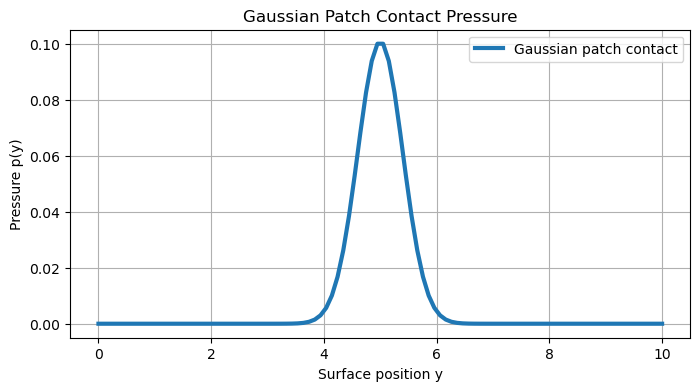

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
n = 100
y = np.linspace(0, 10, n)
y_c = 5.0  # Contact center position
sigma = 0.4  # Width of the Gaussian contact patch
total_load = 1.0  # Total contact load

# TODO: Create a Gaussian patch contact model
p_gauss = np.exp(-0.5* ((y - y_c)/sigma)**2)  # Replace with your implementation to compute the Gaussian pressure distribution
p_gauss = total_load * p_gauss / np.sum(p_gauss)
plt.figure(figsize=(8, 4))
plt.plot(y, p_gauss, linewidth=3, label="Gaussian patch contact")
plt.xlabel("Surface position y")
plt.ylabel("Pressure p(y)")
plt.title("Gaussian Patch Contact Pressure")
plt.legend()
plt.grid(True)
plt.show()


Now build the forward model matrix H.

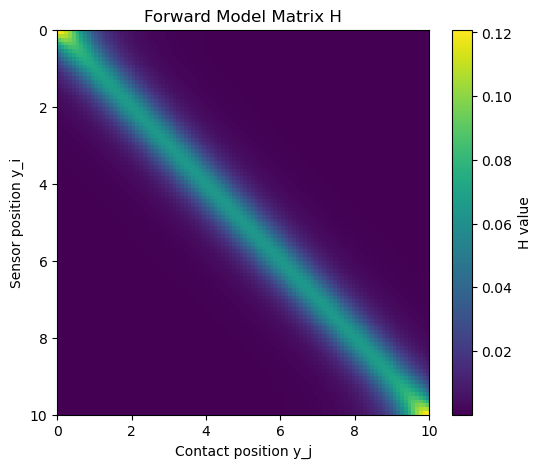

In [7]:
# Build forward model matrix H
z_sensor = 1.0
H = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        # TODO: Compute the contribution of contact at position y_j to sensor reading at position y_i
        # hint: see lecture notes
        dy = abs(y[i] - y[j])
        H[i, j] = 1 / (1 + (dy / z_sensor) ** 2) ** 2
        pass

# TODO: Normalize H so that each row sums to 1
H = H / H.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(H, extent=[y.min(), y.max(), y.max(), y.min()], aspect="auto")
plt.colorbar(label="H value")
plt.xlabel("Contact position y_j")
plt.ylabel("Sensor position y_i")
plt.title("Forward Model Matrix H")
plt.show()


Now generate pressure sensor signal from the Gaussian patch contact model.

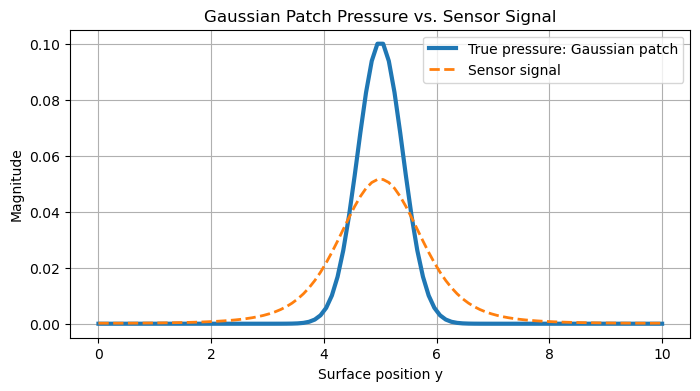

In [9]:
# TODO: Generate sensor signal for the Gaussian patch
s_gauss = H @ p_gauss

plt.figure(figsize=(8, 4))
plt.plot(y, p_gauss, linewidth=3, label="True pressure: Gaussian patch")
plt.plot(y, s_gauss, "--", linewidth=2, label="Sensor signal")
plt.xlabel("Surface position y")
plt.ylabel("Magnitude")
plt.title("Gaussian Patch Pressure vs. Sensor Signal")
plt.legend()
plt.grid(True)
plt.show()


The next step is to compare the models. Given the same contact location, compare the pressure sensor signals obtained by point contact model and Gaussian patch contact model.

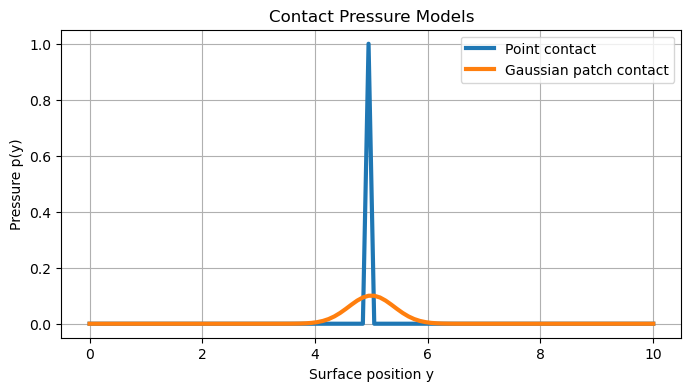

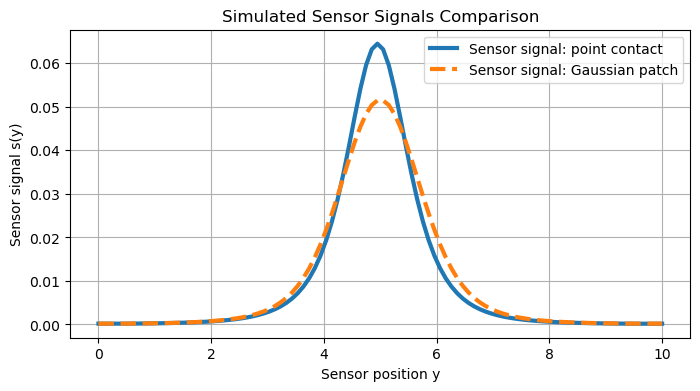

In [10]:
# Compare point contact and Gaussian patch models
p_point = np.zeros(n)
idx_c = np.argmin(np.abs(y - y_c))
p_point[idx_c] = total_load

# TODO: Compute sensor signals for both models
s_point = H @ p_point
s_gauss = H @ p_gauss

plt.figure(figsize=(8, 4))
plt.plot(y, p_point, linewidth=3, label="Point contact")
plt.plot(y, p_gauss, linewidth=3, label="Gaussian patch contact")
plt.xlabel("Surface position y")
plt.ylabel("Pressure p(y)")
plt.title("Contact Pressure Models")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(y, s_point, linewidth=3, label="Sensor signal: point contact")
plt.plot(y, s_gauss, "--", linewidth=3, label="Sensor signal: Gaussian patch")
plt.xlabel("Sensor position y")
plt.ylabel("Sensor signal s(y)")
plt.title("Simulated Sensor Signals Comparison")
plt.legend()
plt.grid(True)
plt.show()


The last part of this assignment is reconstruction of the contact pressure distribution. Reconstruct the contact pressure distribution from the simulated sensor signals. (assume the sensor signal contains random noise – 2% of the peak signal). 

In [ ]:
# Add noise and reconstruct the pressure distributions
noise_level = 0.02  # 2% noise
rng = np.random.default_rng(0)
s_point_noisy = s_point + rng.normal(0, noise_level * np.max(s_point), size=n)
s_gauss_noisy = s_gauss + rng.normal(0, noise_level * np.max(s_gauss), size=n)

# TODO: Implement regularized least squares reconstruction
lambda_reg = 0.01
I = np.eye(n)
p_point_reg = np.linalg.solve(H.T @ H + lambda_reg * I, H.T @ s_point_noisy)
p_gauss_reg = np.linalg.solve(H.T @ H + lambda_reg * I, H.T @ s_gauss_noisy)
plt.figure(figsize=(8, 4))
plt.plot(y, p_point, linewidth=3, label="True pressure: point contact")
plt.plot(y, p_point_reg, "--", linewidth=3, label="Regularized reconstruction")
plt.xlabel("Surface position y")
plt.ylabel("Pressure p(y)")
plt.title("Point Contact Reconstruction")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(y, p_gauss, linewidth=3, label="True pressure: Gaussian patch")
plt.plot(y, p_gauss_reg, "--", linewidth=3, label="Regularized reconstruction")
plt.xlabel("Surface position y")
plt.ylabel("Pressure p(y)")
plt.title("Gaussian Patch Reconstruction")
plt.legend()
plt.grid(True)
plt.show()
